In [1]:
# ============================================================
# CELL 1 - Load Data & Create Impact Metrics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

DATA_PATH = "../data/processed/modeling_data.csv"
df = pd.read_csv(DATA_PATH)

df["co2_per_capita"] = df["co2"] * 1e6 / df["population_co2"]

impact_features = [
    "renewables_share_energy", "renewables_share_elec",
    "renewables_electricity", "fossil_share_energy",
    "gdp_per_capita", "energy_per_capita"
]

print("=" * 60)
print("RENEWABLE ENERGY IMPACT ANALYSIS")
print("=" * 60)
print("Rows:", len(df))
print("Countries:", df["country"].nunique())
print("Year range:", df["year"].min(), "-", df["year"].max())

print("\nImpact variables:")
print(impact_features)

display(df[["country", "year", "co2", "co2_per_capita"] + impact_features].head())

RENEWABLE ENERGY IMPACT ANALYSIS
Rows: 1817
Countries: 79
Year range: 2000 - 2022

Impact variables:
['renewables_share_energy', 'renewables_share_elec', 'renewables_electricity', 'fossil_share_energy', 'gdp_per_capita', 'energy_per_capita']


,country,year,co2,co2_per_capita,renewables_share_energy,renewables_share_elec,renewables_electricity,fossil_share_energy,gdp_per_capita,energy_per_capita
0,Algeria,2000,84.552452,2.735981,0.050011,0.196850,0.05,99.949989,6748.474822,9705.755792
1,Algeria,2001,86.019196,2.745478,0.061328,0.262960,0.07,99.938675,7130.914508,9920.229670
2,Algeria,2002,89.658401,2.823813,0.048507,0.216998,0.06,99.951492,7727.700607,10139.907530
3,Algeria,2003,94.077927,2.923871,0.214343,0.879269,0.26,99.785660,8502.306958,10471.285345
4,Algeria,2004,90.852531,2.784471,0.194495,0.800000,0.25,99.805504,9095.591770,10720.078937


RENEWABLE SHARE & CO₂ RELATIONSHIP
Correlation with total CO₂: -0.0772
Correlation with CO₂ per capita: -0.2117


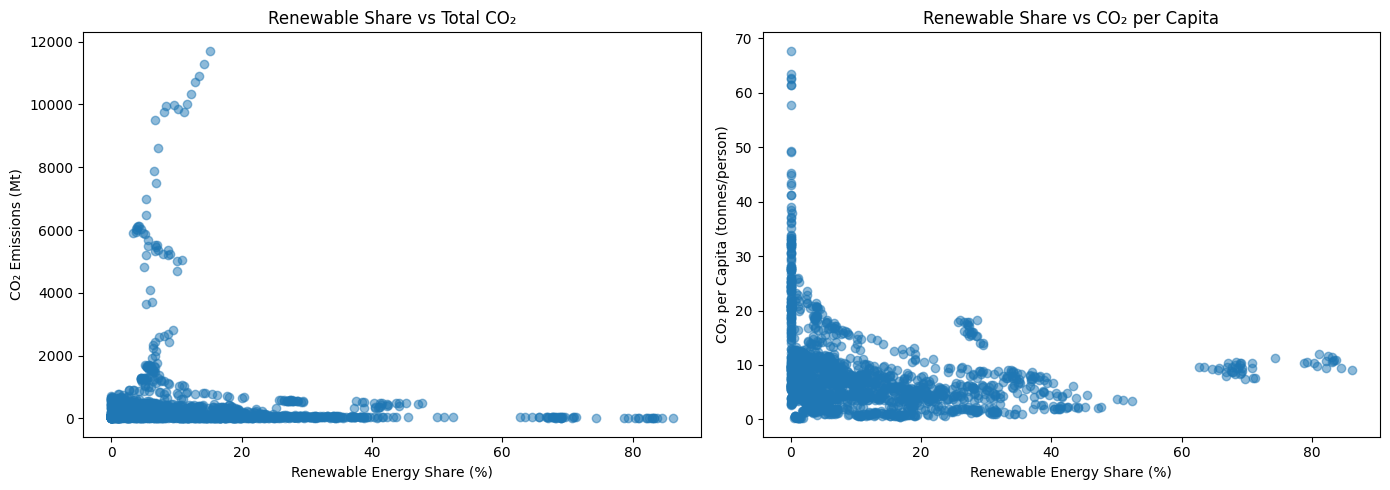

In [2]:
# ============================================================
# CELL 2 - Renewable Share & CO₂ Relationship
# ============================================================

print("=" * 60)
print("RENEWABLE SHARE & CO₂ RELATIONSHIP")
print("=" * 60)

corr_total = df["renewables_share_energy"].corr(df["co2"])
corr_per_capita = df["renewables_share_energy"].corr(df["co2_per_capita"])

print("Correlation with total CO₂:", round(corr_total, 4))
print("Correlation with CO₂ per capita:", round(corr_per_capita, 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["renewables_share_energy"], df["co2"], alpha=0.5)
axes[0].set_xlabel("Renewable Energy Share (%)")
axes[0].set_ylabel("CO₂ Emissions (Mt)")
axes[0].set_title("Renewable Share vs Total CO₂")

axes[1].scatter(df["renewables_share_energy"], df["co2_per_capita"], alpha=0.5)
axes[1].set_xlabel("Renewable Energy Share (%)")
axes[1].set_ylabel("CO₂ per Capita (tonnes/person)")
axes[1].set_title("Renewable Share vs CO₂ per Capita")

plt.tight_layout()
plt.show()

RENEWABLE ADOPTION GROUP ANALYSIS
Renewable adoption group summary:


,renewable_group,average_renewable_share,average_co2,average_co2_per_capita,average_fossil_share,observations
0,Low,0.493,167.462,13.749,97.101,455
1,Moderate,3.965,546.230,7.728,91.498,454
2,High,10.704,727.566,5.943,83.811,454
3,Very High,31.491,116.838,5.723,64.322,454


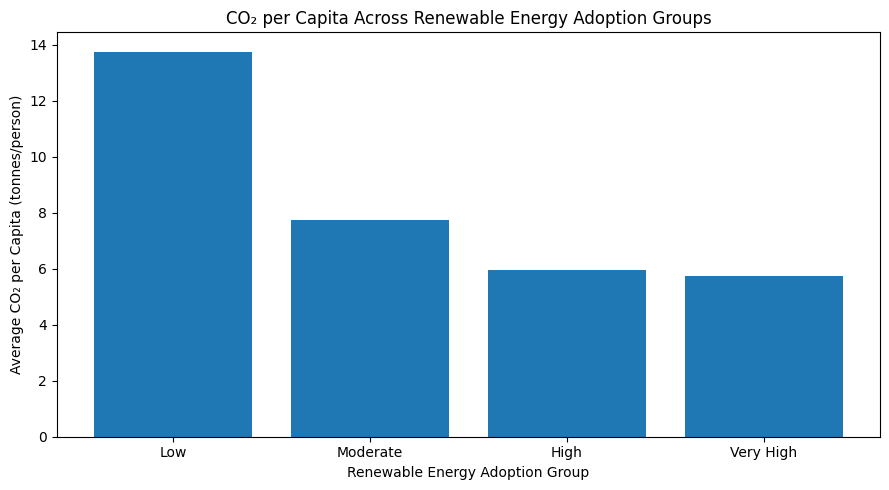

In [3]:
# ============================================================
# CELL 3 - Renewable Adoption Groups
# ============================================================

print("=" * 60)
print("RENEWABLE ADOPTION GROUP ANALYSIS")
print("=" * 60)

df["renewable_group"] = pd.qcut(
    df["renewables_share_energy"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"]
)

group_summary = df.groupby("renewable_group", observed=True).agg(
    average_renewable_share=("renewables_share_energy", "mean"),
    average_co2=("co2", "mean"),
    average_co2_per_capita=("co2_per_capita", "mean"),
    average_fossil_share=("fossil_share_energy", "mean"),
    observations=("co2", "size")
).reset_index()

print("Renewable adoption group summary:")
display(group_summary.round(3))

plt.figure(figsize=(9, 5))
plt.bar(group_summary["renewable_group"], group_summary["average_co2_per_capita"])
plt.xlabel("Renewable Energy Adoption Group")
plt.ylabel("Average CO₂ per Capita (tonnes/person)")
plt.title("CO₂ per Capita Across Renewable Energy Adoption Groups")
plt.tight_layout()
plt.show()

CONTROLLED RENEWABLE IMPACT MODEL
Controlled model R²: 0.8161

Standardized coefficients:


,Feature,Standardized_Coefficient
0,renewables_share_energy,-0.179351
2,gdp_per_capita,0.069990
1,fossil_share_energy,0.149057
3,energy_per_capita,0.825982


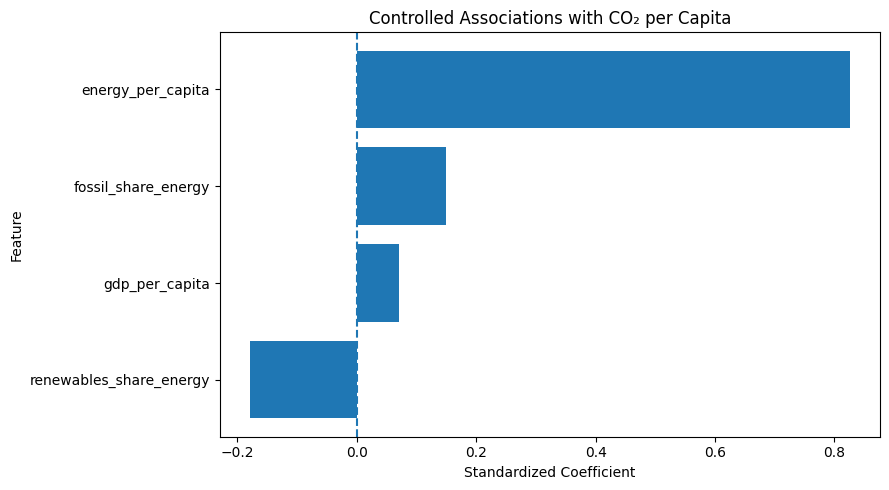

In [4]:
# ============================================================
# CELL 4 - Controlled Renewable Impact Model
# ============================================================

print("=" * 60)
print("CONTROLLED RENEWABLE IMPACT MODEL")
print("=" * 60)

impact_features = [
    "renewables_share_energy", "fossil_share_energy",
    "gdp_per_capita", "energy_per_capita"
]

impact_df = df[["co2_per_capita"] + impact_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(impact_df[impact_features])
y_scaled = StandardScaler().fit_transform(impact_df[["co2_per_capita"]]).ravel()

impact_model = LinearRegression()
impact_model.fit(X_scaled, y_scaled)

impact_results = pd.DataFrame({
    "Feature": impact_features,
    "Standardized_Coefficient": impact_model.coef_
}).sort_values("Standardized_Coefficient")

print("Controlled model R²:", round(impact_model.score(X_scaled, y_scaled), 4))
print("\nStandardized coefficients:")
display(impact_results)

plt.figure(figsize=(9, 5))
plt.barh(impact_results["Feature"], impact_results["Standardized_Coefficient"])
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.title("Controlled Associations with CO₂ per Capita")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

RENEWABLE ENERGY TREND & SUMMARY
Change in average renewable share: 5.71 percentage points
Renewable share in 2000 : 9.91 %
Renewable share in 2022 : 15.62 %


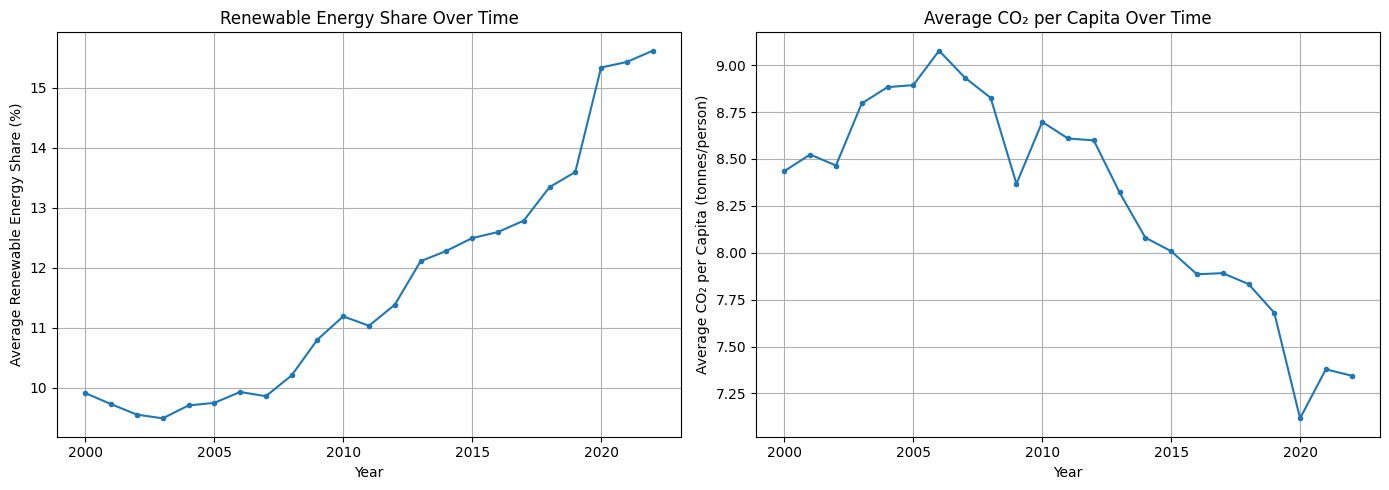

In [5]:
# ============================================================
# CELL 5 - Renewable Energy Trend & Summary
# ============================================================

print("=" * 60)
print("RENEWABLE ENERGY TREND & SUMMARY")
print("=" * 60)

yearly = df.groupby("year").agg(
    renewable_share=("renewables_share_energy", "mean"),
    co2=("co2", "sum"),
    co2_per_capita=("co2_per_capita", "mean")
)

print("Change in average renewable share:",
      round(yearly["renewable_share"].iloc[-1] - yearly["renewable_share"].iloc[0], 2), "percentage points")

print("Renewable share in", yearly.index[0], ":", round(yearly["renewable_share"].iloc[0], 2), "%")
print("Renewable share in", yearly.index[-1], ":", round(yearly["renewable_share"].iloc[-1], 2), "%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly.index, yearly["renewable_share"], marker="o", markersize=3)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Renewable Energy Share (%)")
axes[0].set_title("Renewable Energy Share Over Time")
axes[0].grid(True)

axes[1].plot(yearly.index, yearly["co2_per_capita"], marker="o", markersize=3)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average CO₂ per Capita (tonnes/person)")
axes[1].set_title("Average CO₂ per Capita Over Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()